In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Seasonality v3 — clean comparison vs SPY buy-and-hold

**Replaces v2.** Append after Section 1 (data pull/validation).

**Changes vs v2:**
1. **Slippage = 0** everywhere (fair signal comparison)
2. **All idle days filled with SPY** (apples-to-apples CAGR vs SPY B&H)
3. **`sharpe_diff` only reported when active position ≠ SPY** (otherwise it's slippage noise)
4. **CAGR is the headline metric**, not Sharpe — what we actually want from a long-term sleeve

**The key question this notebook answers:**
*"If I deploy this seasonal rule but otherwise hold SPY, do I end up with more or less money than just holding SPY all year?"*

In [1]:
TICKERS_CORE = ["SPY", "TLT", "IWM", "IJR"]
TICKERS_SECTOR = ["XLE", "XLK", "XLY", "XLP", "XLU", "XLF", "XLI", "XLV", "XLB"]
TICKERS_ALL = TICKERS_CORE + TICKERS_SECTOR

import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from _shared.loaders_data import fetch_historical_data

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

OUT_DIR = Path("./output")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "daily_equity").mkdir(exist_ok=True)
(OUT_DIR / "trades").mkdir(exist_ok=True)

START = datetime(2003, 1, 1)
END = datetime(2025, 5, 1)

# Reload validated prices if running fresh
px = pd.read_parquet(OUT_DIR / "prices_validated.parquet")
rets = px.pct_change()

SLIPPAGE_BPS = 5  # per side

## Section 2 — Setup, BIL data, helpers

In [2]:
from datetime import datetime
from pathlib import Path
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from _shared.loaders_data import fetch_historical_data

# Reload validated prices
px = pd.read_parquet(OUT_DIR / "prices_validated.parquet")

# Add BIL for reference (some strategies may want BIL fill optionally)
raw_bil = fetch_historical_data(["BIL"], TimeFrame(1, TimeFrameUnit.Day), START, END)
bil_df = raw_bil["BIL"].copy()
bil_df.index = bil_df.index.tz_localize(None) if bil_df.index.tz is not None else bil_df.index
px["BIL"] = bil_df["close"].reindex(px.index).ffill()

rets = px.pct_change()
print(f"Prices: {px.index.min().date()} → {px.index.max().date()}, {len(px)} bars")
print(f"Available instruments: {list(px.columns)}")

Fetching BIL...
  2,345 bars
Prices: 2016-01-04 → 2025-05-01, 2434 bars
Available instruments: ['SPY', 'TLT', 'IWM', 'IJR', 'XLE', 'XLK', 'XLY', 'XLP', 'XLU', 'XLF', 'XLI', 'XLV', 'XLB', 'BIL']


In [3]:
# v3 helpers
OUT_DIR = Path("./output")
(OUT_DIR / "daily_equity").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "trades").mkdir(parents=True, exist_ok=True)

SLIPPAGE_BPS = 0  # v3: zero slippage for fair signal comparison

def metrics_from_returns(daily_ret, name=""):
    r = daily_ret.dropna()
    if len(r) < 2 or r.std() == 0:
        return {"name": name, "sharpe": 0, "cagr": 0, "vol": 0, "max_dd": 0, "calmar": 0, "n_days": len(r)}
    eq = (1 + r).cumprod()
    years = len(r) / 252
    cagr = eq.iloc[-1] ** (1 / years) - 1
    vol = r.std() * np.sqrt(252)
    sharpe = r.mean() / r.std() * np.sqrt(252)
    dd = (eq / eq.cummax() - 1).min()
    calmar = cagr / abs(dd) if dd < 0 else np.nan
    return {"name": name, "sharpe": sharpe, "cagr": cagr, "vol": vol, "max_dd": dd, "calmar": calmar, "n_days": len(r)}

def bootstrap_sharpe_pvalue(daily_ret, n_iter=1000, seed=42):
    r = daily_ret.dropna().values
    if len(r) < 30 or r.std() == 0:
        return np.nan
    rng = np.random.RandomState(seed)
    sharpes = np.empty(n_iter)
    for i in range(n_iter):
        sample = rng.choice(r, size=len(r), replace=True)
        sharpes[i] = sample.mean() / sample.std() * np.sqrt(252) if sample.std() > 0 else 0
    return (sharpes <= 0).mean()

def positions_to_returns(weights, returns, slippage_bps=SLIPPAGE_BPS):
    """Daily return = yesterday's weight × today's return, minus slippage on weight changes."""
    w = weights.shift(1).fillna(0)
    gross = (w * returns).sum(axis=1)
    if slippage_bps > 0:
        turnover = (weights - weights.shift(1)).abs().sum(axis=1).fillna(0)
        cost = turnover * (slippage_bps / 10000)
        return gross - cost
    return gross

def positions_to_trades(weights, prices, name):
    rows = []
    for inst in weights.columns:
        w = weights[inst].fillna(0)
        active = w != 0
        starts = active & ~active.shift(1, fill_value=False)
        ends = active & ~active.shift(-1, fill_value=False)
        for s, e in zip(w.index[starts], w.index[ends]):
            direction = "long" if w.loc[s] > 0 else "short"
            ep = prices.loc[s, inst]; xp = prices.loc[e, inst]
            ret_g = (xp/ep - 1) * (1 if direction == "long" else -1)
            rows.append({"entry_time": s, "exit_time": e, "direction": direction,
                         "instrument": inst, "entry_price": ep, "exit_price": xp,
                         "pct_return_gross": ret_g, "exit_reason": "calendar", "stop_price": np.nan})
    return pd.DataFrame(rows).sort_values("entry_time").reset_index(drop=True) if rows else pd.DataFrame()

print("v3 helpers loaded.")

v3 helpers loaded.


In [4]:
def positions_match_spy(weights):
    """Returns True iff the strategy's active days are identical to long SPY.
    These strategies don't have a meaningful diff_sharpe (only slippage noise)."""
    if list(weights.columns) != ["SPY"]:
        return False
    # active positions are 1.0 SPY → on those days, strategy ret = SPY ret exactly
    return ((weights["SPY"] == 0) | (weights["SPY"] == 1.0)).all()

def evaluate_v3(name, weights, slippage_bps=0):
    """
    v3 evaluation:
    - Active-only: strategy returns on active days (NaN on idle)
    - SPY-filled: strategy on active days, SPY on idle days  ← CANONICAL for CAGR
    - diff_sharpe: only meaningful when active position ≠ SPY
    """
    strat_ret = positions_to_returns(weights, rets[weights.columns], slippage_bps)
    active_today = (weights.abs().sum(axis=1) > 0)
    active_yesterday = active_today.shift(1).fillna(False)
    
    # Active-only returns
    active_only_ret = strat_ret.where(active_yesterday)
    
    # SPY-filled (canonical comparison)
    filled_ret = strat_ret.where(active_yesterday, rets["SPY"])
    
    # Diff_sharpe — only valid when active position ≠ SPY
    is_spy_clone = positions_match_spy(weights)
    if is_spy_clone:
        diff_sharpe = np.nan
        p_diff = np.nan
    else:
        spy_active = rets["SPY"].where(active_yesterday)
        diff_ret = (active_only_ret - spy_active).dropna()
        diff_metrics = metrics_from_returns(diff_ret, f"{name}_diff")
        diff_sharpe = diff_metrics["sharpe"]
        p_diff = bootstrap_sharpe_pvalue(diff_ret)
    
    m_active = metrics_from_returns(active_only_ret, f"{name}_active")
    m_filled = metrics_from_returns(filled_ret, f"{name}_filled")
    p_filled = bootstrap_sharpe_pvalue(filled_ret)
    
    eq_filled = (1 + filled_ret.fillna(0)).cumprod()
    eq_filled.to_frame("equity").to_csv(OUT_DIR / "daily_equity" / f"{name}_v3.csv")
    
    trades = positions_to_trades(weights, px, name)
    if len(trades) > 0:
        trades.to_csv(OUT_DIR / "trades" / f"{name}_v3.csv", index=False)
    
    return {
        "name": name,
        "is_spy_clone": is_spy_clone,
        "active_days": int(active_today.sum()),
        "pct_active": active_today.mean() * 100,
        "n_trades": len(trades),
        "active": m_active,
        "filled": m_filled,
        "diff_sharpe": diff_sharpe,
        "p_filled": p_filled,
        "p_diff": p_diff,
        "strat_ret": strat_ret,
        "active_only_ret": active_only_ret,
        "filled_ret": filled_ret,
        "eq_filled": eq_filled,
        "weights": weights,
    }

def print_v3(r, spy_cagr):
    delta_cagr = r["filled"]["cagr"] - spy_cagr
    flag = "✅" if delta_cagr > 0 else "❌"
    print(f"  Active days:  {r['active_days']:>5} ({r['pct_active']:.0f}%)   Trades: {r['n_trades']}")
    print(f"  Active-only: Sharpe {r['active']['sharpe']:>5.2f}  CAGR {r['active']['cagr']:>6.1%}")
    print(f"  SPY-filled:  Sharpe {r['filled']['sharpe']:>5.2f}  CAGR {r['filled']['cagr']:>6.1%}  MaxDD {r['filled']['max_dd']:>6.1%}  ΔCAGR vs SPY {flag} {delta_cagr:+.1%}")
    if not r["is_spy_clone"]:
        print(f"  Diff Sharpe: {r['diff_sharpe']:>5.2f}  (active position ≠ SPY)   p={r['p_diff']:.3f}")
    else:
        print(f"  Diff Sharpe: N/A  (strategy is long SPY when active — diff would be slippage noise)")

spy_ret_full = rets["SPY"]
spy_eq_full = (1 + spy_ret_full.fillna(0)).cumprod()
spy_metrics = metrics_from_returns(spy_ret_full, "SPY_BH")
SPY_CAGR = spy_metrics["cagr"]
print(f"\nSPY benchmark: Sharpe {spy_metrics['sharpe']:.2f} | CAGR {SPY_CAGR:.1%} | MaxDD {spy_metrics['max_dd']:.1%}")


SPY benchmark: Sharpe 0.77 | CAGR 12.8% | MaxDD -33.8%


## Section 3 — Sell in May / Halloween

In [5]:
winter_mask = px.index.month.isin([11, 12, 1, 2, 3, 4])

# v3a: SPY winter only, idle May-Oct → SPY-filled means we hold SPY all year (= SPY benchmark)
# That's not interesting. The point of sell-in-May is the *defensive* leg.
# We compare three meaningful variants:
#  - sellmay_tlt: SPY winter, TLT summer (always invested)
#  - sellmay_bil: SPY winter, BIL summer (defensive cash) → vs SPY-fill comparison

results = {}

# Variant A: SPY winter, TLT summer
w_sellmay_tlt = pd.DataFrame(0.0, index=px.index, columns=["SPY", "TLT"])
w_sellmay_tlt.loc[winter_mask, "SPY"] = 1.0
w_sellmay_tlt.loc[~winter_mask, "TLT"] = 1.0

# Variant B: SPY winter, BIL summer
w_sellmay_bil = pd.DataFrame(0.0, index=px.index, columns=["SPY", "BIL"])
w_sellmay_bil.loc[winter_mask, "SPY"] = 1.0
w_sellmay_bil.loc[~winter_mask, "BIL"] = 1.0

for name, w in [("sellmay_tlt", w_sellmay_tlt), ("sellmay_bil", w_sellmay_bil)]:
    print(f"\n=== {name} ===")
    r = evaluate_v3(name, w)
    print_v3(r, SPY_CAGR)
    results[name] = r


=== sellmay_tlt ===
  Active days:   2434 (100%)   Trades: 20
  Active-only: Sharpe  0.38  CAGR   5.2%
  SPY-filled:  Sharpe  0.38  CAGR   5.2%  MaxDD -35.4%  ΔCAGR vs SPY ❌ -7.6%
  Diff Sharpe: -0.48  (active position ≠ SPY)   p=0.938

=== sellmay_bil ===
  Active days:   2434 (100%)   Trades: 20
  Active-only: Sharpe  0.56  CAGR   7.3%
  SPY-filled:  Sharpe  0.56  CAGR   7.3%  MaxDD -33.8%  ΔCAGR vs SPY ❌ -5.5%
  Diff Sharpe: -0.54  (active position ≠ SPY)   p=0.959


## Section 4 — Best Six Months + MACD

Two variants matching sellmay structure: TLT-summer and BIL-summer, with MACD timing on the entry/exit.

In [8]:
# Monthly MACD signal
spy_monthly = px["SPY"].resample("M").last()
ema_fast_m = spy_monthly.ewm(span=12, adjust=False).mean()
ema_slow_m = spy_monthly.ewm(span=26, adjust=False).mean()
macd_m = ema_fast_m - ema_slow_m
signal_m = macd_m.ewm(span=9, adjust=False).mean()
macd_pos_monthly = (macd_m - signal_m) > 0
macd_pos_daily = macd_pos_monthly.reindex(px.index, method="ffill").fillna(False)

# State machine
in_pos = pd.Series(False, index=px.index)
state = False
month_end_set = set(px.resample("M").last().index)
for i, dt in enumerate(px.index):
    if dt in month_end_set or i == 0:
        m = dt.month
        macd_pos = bool(macd_pos_daily.iloc[i])
        if not state:
            if m in [10, 11, 12, 1, 2, 3, 4] and macd_pos:
                state = True
        else:
            if m in [4, 5, 6, 7, 8, 9] and not macd_pos:
                state = False
    in_pos.iloc[i] = state

# Variant A: BSM + TLT when out
w_bsm_tlt = pd.DataFrame(0.0, index=px.index, columns=["SPY", "TLT"])
w_bsm_tlt.loc[in_pos, "SPY"] = 1.0
w_bsm_tlt.loc[~in_pos, "TLT"] = 1.0

# Variant B: BSM + BIL when out
w_bsm_bil = pd.DataFrame(0.0, index=px.index, columns=["SPY", "BIL"])
w_bsm_bil.loc[in_pos, "SPY"] = 1.0
w_bsm_bil.loc[~in_pos, "BIL"] = 1.0

for name, w in [("bsm_macd_tlt", w_bsm_tlt), ("bsm_macd_bil", w_bsm_bil)]:
    print(f"\n=== {name} ===")
    r = evaluate_v3(name, w)
    print_v3(r, SPY_CAGR)
    results[name] = r


=== bsm_macd_tlt ===
  Active days:   2434 (100%)   Trades: 9
  Active-only: Sharpe  0.52  CAGR   7.9%
  SPY-filled:  Sharpe  0.52  CAGR   7.9%  MaxDD -35.8%  ΔCAGR vs SPY ❌ -4.9%
  Diff Sharpe: -0.33  (active position ≠ SPY)   p=0.853

=== bsm_macd_bil ===
  Active days:   2434 (100%)   Trades: 9
  Active-only: Sharpe  0.70  CAGR   9.7%
  SPY-filled:  Sharpe  0.70  CAGR   9.7%  MaxDD -33.8%  ΔCAGR vs SPY ❌ -3.1%
  Diff Sharpe: -0.33  (active position ≠ SPY)   p=0.842


## Section 5 — Presidential Cycle

In [9]:
year_to_cycle = {2016:4, 2017:1, 2018:2, 2019:3, 2020:4,
                  2021:1, 2022:2, 2023:3, 2024:4, 2025:1}
cycle_yr = pd.Series([year_to_cycle.get(y, np.nan) for y in px.index.year], index=px.index)

# SPY in Y3, TLT in Y2, idle (will be SPY-filled) in Y1/Y4
w_pres = pd.DataFrame(0.0, index=px.index, columns=["SPY", "TLT"])
w_pres.loc[cycle_yr == 3, "SPY"] = 1.0
w_pres.loc[cycle_yr == 2, "TLT"] = 1.0

print("=== presidential_cycle ===")
r = evaluate_v3("presidential_cycle", w_pres)
print_v3(r, SPY_CAGR)
results["presidential_cycle"] = r

=== presidential_cycle ===
  Active days:   1042 (43%)   Trades: 4
  Active-only: Sharpe  0.31  CAGR   3.4%
  SPY-filled:  Sharpe  0.74  CAGR  11.5%  MaxDD -34.9%  ΔCAGR vs SPY ❌ -1.2%
  Diff Sharpe: -0.17  (active position ≠ SPY)   p=0.642


## Section 6 — January Effect

In [10]:
jan_mask = px.index.month == 1
is_dec_late = (px.index.month == 12) & (px.index.day >= 15)
is_feb_early = (px.index.month == 2) & (px.index.day <= 15)
small_cap_window = is_dec_late | jan_mask | is_feb_early

# 6a: IWM Jan, SPY rest (always invested — no idle, so filled = active)
w_jan_a = pd.DataFrame(0.0, index=px.index, columns=["IWM", "SPY"])
w_jan_a.loc[jan_mask, "IWM"] = 1.0
w_jan_a.loc[~jan_mask, "SPY"] = 1.0

# 6b: IWM Dec15-Feb15 only, idle other days → SPY-fill: hold SPY 10 months, IWM 2 months
w_jan_b = pd.DataFrame(0.0, index=px.index, columns=["IWM"])
w_jan_b.loc[small_cap_window, "IWM"] = 1.0

# 6c: IJR Jan only, SPY-filled rest
w_jan_c = pd.DataFrame(0.0, index=px.index, columns=["IJR"])
w_jan_c.loc[jan_mask, "IJR"] = 1.0

for name, w in [("january_iwm_jan_spy_rest", w_jan_a),
                ("january_iwm_window", w_jan_b),
                ("january_ijr_only", w_jan_c)]:
    print(f"\n=== {name} ===")
    r = evaluate_v3(name, w)
    print_v3(r, SPY_CAGR)
    results[name] = r


=== january_iwm_jan_spy_rest ===
  Active days:   2434 (100%)   Trades: 20
  Active-only: Sharpe  0.71  CAGR  11.9%
  SPY-filled:  Sharpe  0.71  CAGR  11.9%  MaxDD -33.8%  ΔCAGR vs SPY ❌ -0.9%
  Diff Sharpe: -0.23  (active position ≠ SPY)   p=0.765

=== january_iwm_window ===
  Active days:    436 (18%)   Trades: 10
  Active-only: Sharpe  0.89  CAGR  16.6%
  SPY-filled:  Sharpe  0.73  CAGR  12.5%  MaxDD -34.3%  ΔCAGR vs SPY ❌ -0.3%
  Diff Sharpe: -0.08  (active position ≠ SPY)   p=0.537

=== january_ijr_only ===
  Active days:    221 (9%)   Trades: 10
  Active-only: Sharpe  0.92  CAGR  16.9%
  SPY-filled:  Sharpe  0.72  CAGR  12.2%  MaxDD -34.4%  ΔCAGR vs SPY ❌ -0.6%
  Diff Sharpe: -0.45  (active position ≠ SPY)   p=0.669


## Section 7 — Q4 Seasonality

In [11]:
q4_mask = px.index.month.isin([10, 11, 12])

# 7a: SPY Q4, TLT rest (always invested)
w_q4_tlt = pd.DataFrame(0.0, index=px.index, columns=["SPY", "TLT"])
w_q4_tlt.loc[q4_mask, "SPY"] = 1.0
w_q4_tlt.loc[~q4_mask, "TLT"] = 1.0

# 7b: SPY Q4, BIL rest (always invested)
w_q4_bil = pd.DataFrame(0.0, index=px.index, columns=["SPY", "BIL"])
w_q4_bil.loc[q4_mask, "SPY"] = 1.0
w_q4_bil.loc[~q4_mask, "BIL"] = 1.0

for name, w in [("q4_spy_tlt", w_q4_tlt), ("q4_spy_bil", w_q4_bil)]:
    print(f"\n=== {name} ===")
    r = evaluate_v3(name, w)
    print_v3(r, SPY_CAGR)
    results[name] = r


=== q4_spy_tlt ===
  Active days:   2434 (100%)   Trades: 19
  Active-only: Sharpe  0.44  CAGR   5.6%
  SPY-filled:  Sharpe  0.44  CAGR   5.6%  MaxDD -34.1%  ΔCAGR vs SPY ❌ -7.2%
  Diff Sharpe: -0.31  (active position ≠ SPY)   p=0.841

=== q4_spy_bil ===
  Active days:   2434 (100%)   Trades: 19
  Active-only: Sharpe  0.85  CAGR   6.2%
  SPY-filled:  Sharpe  0.85  CAGR   6.2%  MaxDD -19.2%  ΔCAGR vs SPY ❌ -6.6%
  Diff Sharpe: -0.45  (active position ≠ SPY)   p=0.928


## Section 8 — Sector Seasonal (academic calendar)

In [13]:
month_to_basket = {
    1:  ["XLY", "XLK", "XLB"],
    2:  ["XLK", "XLY"],
    3:  ["XLB", "XLE"],
    4:  ["XLY", "XLK", "XLI", "XLB"],
    5:  ["XLU", "XLV"],
    6:  ["XLP", "XLV", "XLU"],
    7:  ["XLV", "XLP"],
    8:  ["XLP", "XLU"],
    9:  None,  # SPY-fill in Sep
    10: ["XLK", "XLY", "XLI"],
    11: ["XLY", "XLK"],
    12: ["XLY", "XLK", "XLI"],
}

all_sectors = list(set(s for v in month_to_basket.values() if v for s in v))
w_seasonal = pd.DataFrame(0.0, index=px.index, columns=all_sectors)
for m_num in range(1, 13):
    basket = month_to_basket[m_num]
    if basket is None:
        continue
    mask = px.index.month == m_num
    weight_each = 1.0 / len(basket)
    for s in basket:
        w_seasonal.loc[mask, s] = weight_each

print("=== sector_seasonal_academic (idle Sep → SPY-fill) ===")
r = evaluate_v3("sector_seasonal_academic", w_seasonal)
print_v3(r, SPY_CAGR)
results["sector_seasonal_academic"] = r

=== sector_seasonal_academic (idle Sep → SPY-fill) ===
  Active days:   2242 (92%)   Trades: 136
  Active-only: Sharpe  0.72  CAGR  13.3%
  SPY-filled:  Sharpe  0.60  CAGR  10.4%  MaxDD -45.5%  ΔCAGR vs SPY ❌ -2.4%
  Diff Sharpe: -0.19  (active position ≠ SPY)   p=0.728


## Section 9 — Month-of-Year Tilt (Walk-Forward, top-3 EW)

In [15]:
sector_etfs = TICKERS_SECTOR
sector_monthly_ret = px[sector_etfs].resample("M").last().pct_change()
min_train_months = 36
TOP_K = 3

target_basket_by_month = {}
for i, month_end in enumerate(sector_monthly_ret.index):
    if i < min_train_months: continue
    next_month = (month_end + pd.offsets.MonthEnd(1)).month
    train = sector_monthly_ret.iloc[:i+1]
    same_cal = train[train.index.month == next_month]
    if len(same_cal) < 3: continue
    top_k = same_cal.mean().nlargest(TOP_K).index.tolist()
    target_basket_by_month[month_end] = top_k

w_moy = pd.DataFrame(0.0, index=px.index, columns=sector_etfs)
for month_end, basket in target_basket_by_month.items():
    next_start = month_end + pd.offsets.MonthBegin(1)
    next_end = next_start + pd.offsets.MonthEnd(0)
    mask = (px.index >= next_start) & (px.index <= next_end)
    weight_each = 1.0 / len(basket)
    for s in basket:
        w_moy.loc[mask, s] = weight_each

print(f"=== month_of_year_tilt (top-{TOP_K} EW, walk-forward, SPY-fill on training period) ===")
r = evaluate_v3("month_of_year_tilt", w_moy)
print_v3(r, SPY_CAGR)
results["month_of_year_tilt"] = r

=== month_of_year_tilt (top-3 EW, walk-forward, SPY-fill on training period) ===
  Active days:   1630 (67%)   Trades: 167
  Active-only: Sharpe  0.47  CAGR   8.2%
  SPY-filled:  Sharpe  0.56  CAGR   9.3%  MaxDD -40.6%  ΔCAGR vs SPY ❌ -3.5%
  Diff Sharpe: -0.51  (active position ≠ SPY)   p=0.903


## Section 10 — Skip September

In [16]:
sep_mask = px.index.month == 9

# 10a: SPY 11mo, TLT in Sep (always invested)
w_skipsep_tlt = pd.DataFrame(0.0, index=px.index, columns=["SPY", "TLT"])
w_skipsep_tlt.loc[~sep_mask, "SPY"] = 1.0
w_skipsep_tlt.loc[sep_mask, "TLT"] = 1.0

# 10b: SPY 11mo, BIL in Sep (always invested)
w_skipsep_bil = pd.DataFrame(0.0, index=px.index, columns=["SPY", "BIL"])
w_skipsep_bil.loc[~sep_mask, "SPY"] = 1.0
w_skipsep_bil.loc[sep_mask, "BIL"] = 1.0

for name, w in [("skip_september_tlt", w_skipsep_tlt), ("skip_september_bil", w_skipsep_bil)]:
    print(f"\n=== {name} ===")
    r = evaluate_v3(name, w)
    print_v3(r, SPY_CAGR)
    results[name] = r


=== skip_september_tlt ===
  Active days:   2434 (100%)   Trades: 19
  Active-only: Sharpe  0.72  CAGR  11.9%
  SPY-filled:  Sharpe  0.72  CAGR  11.9%  MaxDD -33.8%  ΔCAGR vs SPY ❌ -0.9%
  Diff Sharpe: -0.14  (active position ≠ SPY)   p=0.671

=== skip_september_bil ===
  Active days:   2434 (100%)   Trades: 19
  Active-only: Sharpe  0.88  CAGR  14.8%
  SPY-filled:  Sharpe  0.88  CAGR  14.8%  MaxDD -33.8%  ΔCAGR vs SPY ✅ +2.0%
  Diff Sharpe:  0.39  (active position ≠ SPY)   p=0.114


## Section 11 — Master Comparison

**The key column: `delta_cagr`** — strategy CAGR minus SPY CAGR. Positive = strategy beat SPY in deployable terms.

In [17]:
rows = []
for name, r in results.items():
    rows.append({
        "strategy": name,
        "delta_cagr": r["filled"]["cagr"] - SPY_CAGR,
        "cagr_filled": r["filled"]["cagr"],
        "sharpe_filled": r["filled"]["sharpe"],
        "maxdd_filled": r["filled"]["max_dd"],
        "sharpe_active": r["active"]["sharpe"],
        "diff_sharpe": r["diff_sharpe"],
        "p_diff": r["p_diff"],
        "pct_active": r["pct_active"],
        "n_trades": r["n_trades"],
    })
summary = pd.DataFrame(rows).set_index("strategy").sort_values("delta_cagr", ascending=False)
summary.loc["SPY_BH"] = {"delta_cagr": 0, "cagr_filled": SPY_CAGR, "sharpe_filled": spy_metrics["sharpe"],
                          "maxdd_filled": spy_metrics["max_dd"], "sharpe_active": np.nan,
                          "diff_sharpe": np.nan, "p_diff": np.nan, "pct_active": 100, "n_trades": np.nan}

disp = summary.copy()
disp["delta_cagr"] = disp["delta_cagr"].map(lambda x: f"{x:+.1%}" if pd.notna(x) else "")
for c in ["cagr_filled", "maxdd_filled"]:
    disp[c] = disp[c].map(lambda x: f"{x:.1%}" if pd.notna(x) else "")
for c in ["sharpe_filled", "sharpe_active", "diff_sharpe"]:
    disp[c] = disp[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "N/A")
disp["p_diff"] = disp["p_diff"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")
disp["pct_active"] = disp["pct_active"].map(lambda x: f"{x:.0f}%")
print("=" * 130)
print("v3 SUMMARY — sorted by ΔCAGR vs SPY (this is the metric we want)")
print("=" * 130)
print(disp.to_string())

v3 SUMMARY — sorted by ΔCAGR vs SPY (this is the metric we want)
                         delta_cagr cagr_filled sharpe_filled maxdd_filled sharpe_active diff_sharpe p_diff pct_active  n_trades
strategy                                                                                                                        
skip_september_bil            +2.0%       14.8%          0.88       -33.8%          0.88        0.39  0.114       100%      19.0
january_iwm_window            -0.3%       12.5%          0.73       -34.3%          0.89       -0.08  0.537        18%      10.0
january_ijr_only              -0.6%       12.2%          0.72       -34.4%          0.92       -0.45  0.669         9%      10.0
skip_september_tlt            -0.9%       11.9%          0.72       -33.8%          0.72       -0.14  0.671       100%      19.0
january_iwm_jan_spy_rest      -0.9%       11.9%          0.71       -33.8%          0.71       -0.23  0.765       100%      20.0
presidential_cycle            -1

In [18]:
# Regime-conditional CAGR (the headline metric)
covid_window = (px.index >= "2020-02-15") & (px.index <= "2020-08-31")
bear_2022 = (px.index >= "2022-01-01") & (px.index <= "2022-12-31")

def cagr_subperiod(daily_ret, mask):
    r = daily_ret[~mask].dropna()
    if len(r) < 30: return np.nan
    eq = (1 + r).cumprod()
    yrs = len(r) / 252
    return eq.iloc[-1] ** (1/yrs) - 1

rows_r = []
for name, r in results.items():
    fr = r["filled_ret"]
    rows_r.append({
        "strategy": name,
        "cagr_full": r["filled"]["cagr"],
        "cagr_ex_covid": cagr_subperiod(fr, covid_window),
        "cagr_ex_2022": cagr_subperiod(fr, bear_2022),
        "cagr_ex_both": cagr_subperiod(fr, covid_window | bear_2022),
    })
regime_df = pd.DataFrame(rows_r).set_index("strategy").sort_values("cagr_full", ascending=False)
regime_df.loc["SPY_BH"] = {
    "cagr_full": SPY_CAGR,
    "cagr_ex_covid": cagr_subperiod(spy_ret_full, covid_window),
    "cagr_ex_2022": cagr_subperiod(spy_ret_full, bear_2022),
    "cagr_ex_both": cagr_subperiod(spy_ret_full, covid_window | bear_2022),
}

disp_r = regime_df.copy()
for c in disp_r.columns:
    disp_r[c] = disp_r[c].map(lambda x: f"{x:.1%}" if pd.notna(x) else "")
print("=" * 80)
print("REGIME-CONDITIONAL CAGR (filled)")
print("=" * 80)
print(disp_r.to_string())

REGIME-CONDITIONAL CAGR (filled)
                         cagr_full cagr_ex_covid cagr_ex_2022 cagr_ex_both
strategy                                                                  
skip_september_bil           14.8%         15.2%        18.4%        19.1%
january_iwm_window           12.5%         12.7%        16.8%        17.4%
january_ijr_only             12.2%         12.4%        16.7%        17.3%
skip_september_tlt           11.9%         12.1%        15.8%        16.3%
january_iwm_jan_spy_rest     11.9%         12.1%        16.7%        17.3%
presidential_cycle           11.5%         11.7%        17.6%        18.2%
sector_seasonal_academic     10.4%         13.5%        13.7%        17.4%
bsm_macd_bil                  9.7%         12.1%        12.6%        15.5%
month_of_year_tilt            9.3%         10.3%        13.1%        14.5%
bsm_macd_tlt                  7.9%         10.4%        12.4%        15.7%
sellmay_bil                   7.3%          9.8%         9.8%      

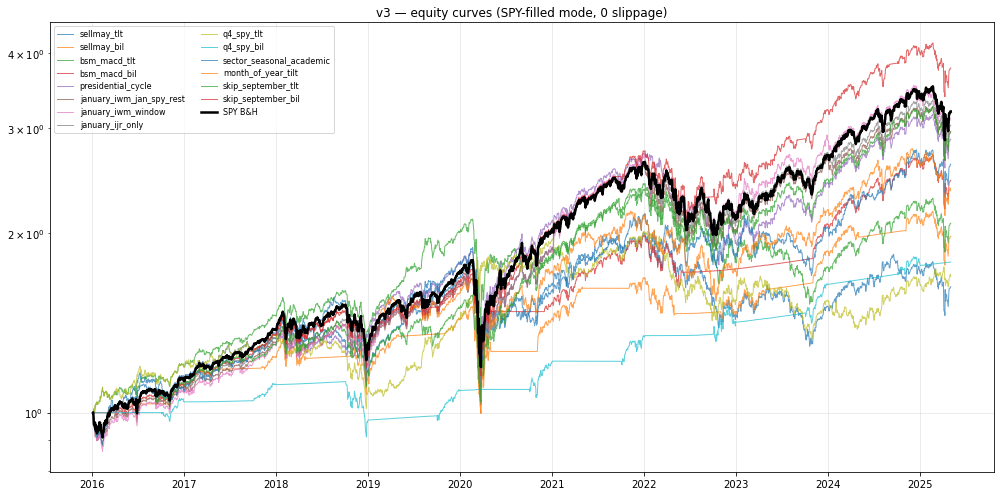

In [19]:
# Equity curve overlay
fig, ax = plt.subplots(figsize=(14, 7))
for name, r in results.items():
    eq = r["eq_filled"]
    ax.plot(np.asarray(eq.index), np.asarray(eq.values), lw=1.0, alpha=0.7, label=name)
ax.plot(np.asarray(spy_eq_full.index), np.asarray(spy_eq_full.values), lw=2.5, color="black", label="SPY B&H")
ax.set_yscale("log")
ax.set_title("v3 — equity curves (SPY-filled mode, 0 slippage)")
ax.legend(fontsize=8, ncol=2, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# Save
import json
summary.to_csv(OUT_DIR / "seasonality_v3_summary.csv")
regime_df.to_csv(OUT_DIR / "seasonality_v3_regime.csv")
print(f"Saved v3 outputs to {OUT_DIR}")